---
title: "Exercício: SARIMA no comércio varejista brasileiro"
format: html
jupyter: python3
---

## Sobre o exercício

A base é a **PMC** (Pesquisa Mensal do Comércio) do IBGE: índice de volume de vendas no **comércio varejista ampliado** (inclui veículos e materiais de construção), por **Unidade da Federação**, mensal de jan/2004 em diante. Base 2022 = 100, **sem ajuste sazonal**.

Você receberá **uma UF de interesse**, e deve aplicar a análise abaixo:

Setup

1. Criar repositório no GitHub para o exercício, e configurar o GitHub Pages para servir o conteúdo do repositório.
2. Clonar o repositório e criar um arquivo chamado `template-exercicio-sarima.qmd` (pode usar o template deste exercício, ou criar do zero, e pode usar jupyter notebook no lugar de Quarto, basta converter usando o comando `quarto convert`).
3. Configure o `uv` com um `.venv` para gerenciar as dependências do exercício (pode usar o `requirements.txt` deste repositório como base, ou criar o seu do zero). Obs: Não é para subir a pasta `.venv` no GitHub, ele precisa estar no seu `.gitignore`.

Código

3. Análise descritiva (linha, ACF, PACF, diferenciação) e diagnóstico de tendência/sazonalidade.
4. Testes de raiz unitária (ADF, KPSS) e estimativa de `ndiffs`.
5. Ajuste de SARIMA via `AutoARIMA(season_length=12)`.
6. Diagnóstico dos resíduos.
7. Previsão de 24 meses à frente, com intervalos de 80% e 95%.

Análise e entrega

8. Discussão dos resultados (perguntas no final).
9. Compilar este arquivo em um relatório em HTML chamado index.html e subir no repositório do GitHub que você criou para este lab. 
10. Configure as github pages para servir o conteúdo do repositório, e compartilhe o link no formulário de entrega do BB.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, ARIMA

In [8]:
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12
})

INSPER_RED = '#E50505'
INSPER_TURQUESA = '#3ACC9F'
INSPER_GRAY = '#5B5B5B'

## Carregando a base PMC

A base já foi pré-processada para conter apenas as colunas relevantes, e já no formato "long" (uma linha por data + UF). O nome da coluna de data é "data", e a coluna de interesse (índice de volume) é "volume_idx". A coluna "uf" indica a Unidade da Federação.

In [2]:
pmc = pd.read_csv("https://github.com/padsInsper/202632-fa/releases/download/data/pmc_volume_uf.csv")

## Escolha sua UF

In [4]:
pmc = pd.read_csv("https://github.com/padsInsper/202632-fa/releases/download/data/pmc_volume_uf.csv")
print(pmc["uf"].unique())

<ArrowStringArray>
[               'Acre',             'Alagoas',               'Amapá',
            'Amazonas',               'Bahia',               'Ceará',
    'Distrito Federal',      'Espírito Santo',               'Goiás',
            'Maranhão',         'Mato Grosso',  'Mato Grosso do Sul',
        'Minas Gerais',              'Paraná',             'Paraíba',
                'Pará',          'Pernambuco',               'Piauí',
 'Rio Grande do Norte',   'Rio Grande do Sul',      'Rio de Janeiro',
            'Rondônia',             'Roraima',      'Santa Catarina',
             'Sergipe',           'São Paulo',           'Tocantins']
Length: 27, dtype: str


In [5]:
MINHA_UF = "Amazonas" 


df_sf = (
    pmc.query("uf == @MINHA_UF")
    .rename(columns={"uf": "unique_id", "data": "ds", "volume_idx": "y"})
    [["unique_id", "ds", "y"]]
    .reset_index(drop=True)
)

df_sf.head()

,unique_id,ds,y
0,Amazonas,2004-01-01,34.49351
1,Amazonas,2004-02-01,31.31977
2,Amazonas,2004-03-01,35.16166
3,Amazonas,2004-04-01,36.33094
4,Amazonas,2004-05-01,42.51137


## Análise descritiva

In [ ]:
def plotar_diagnostico(serie, datas, titulo="Série", lags=36):
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))

    axes[0].plot(datas, serie, color=INSPER_RED, linewidth=0.8)
    axes[0].set_title(titulo, fontweight='bold', fontsize=14)
    axes[0].axhline(y=serie.mean(), color=INSPER_GRAY, linestyle='--', alpha=0.5)

    plot_acf(serie.dropna(), ax=axes[1], lags=lags, zero=False,
             color=INSPER_GRAY, vlines_kwargs={'colors': INSPER_GRAY})
    axes[1].set_title('Autocorrelação (ACF)')

    plot_pacf(serie.dropna(), ax=axes[2], lags=lags, zero=False,
              color=INSPER_GRAY, vlines_kwargs={'colors': INSPER_GRAY})
    axes[2].set_title('Autocorrelação Parcial (PACF)')

    plt.tight_layout()
    plt.show()

plotar_diagnostico(df_sf["y"], df_sf["ds"], f'PMC — Índice de Volume de Vendas ({MINHA_UF})')

## Modelagem

In [ ]:
def testar_estacionariedade(serie, nome="Série"):
    print(f"{'='*50}")
    print(f"Testes de Estacionariedade — {nome}")
    print(f"{'='*50}\n")

    # ADF
    resultado_adf = adfuller(serie.dropna(), autolag='AIC')
    print(f"Teste ADF (H0: raiz unitária)")
    print(f"  Estatística: {resultado_adf[0]:.4f}")
    print(f"  p-valor:     {resultado_adf[1]:.4f}")
    if resultado_adf[1] < 0.05:
        print(f"  → Rejeita H0: evidência de estacionariedade\n")
    else:
        print(f"  → Não rejeita H0: evidência de raiz unitária\n")

    # KPSS
    resultado_kpss = kpss(serie.dropna(), regression='c', nlags='auto')
    print(f"Teste KPSS (H0: estacionária)")
    print(f"  Estatística: {resultado_kpss[0]:.4f}")
    print(f"  p-valor:     {resultado_kpss[1]:.4f}")
    if resultado_kpss[1] < 0.05:
        print(f"  → Rejeita H0: evidência de não-estacionariedade\n")
    else:
        print(f"  → Não rejeita H0: evidência de estacionariedade\n")


testar_estacionariedade(df_sf["y"], f'PMC {MINHA_UF}')

Testes de Estacionariedade — PMC Amazonas

Teste ADF (H0: raiz unitária)
  Estatística: -1.7801
  p-valor:     0.3904
  → Não rejeita H0: evidência de raiz unitária

Teste KPSS (H0: estacionária)
  Estatística: 2.0079
  p-valor:     0.0100
  → Rejeita H0: evidência de não-estacionariedade

CONCLUSÃO: Série provavelmente NÃO ESTACIONÁRIA


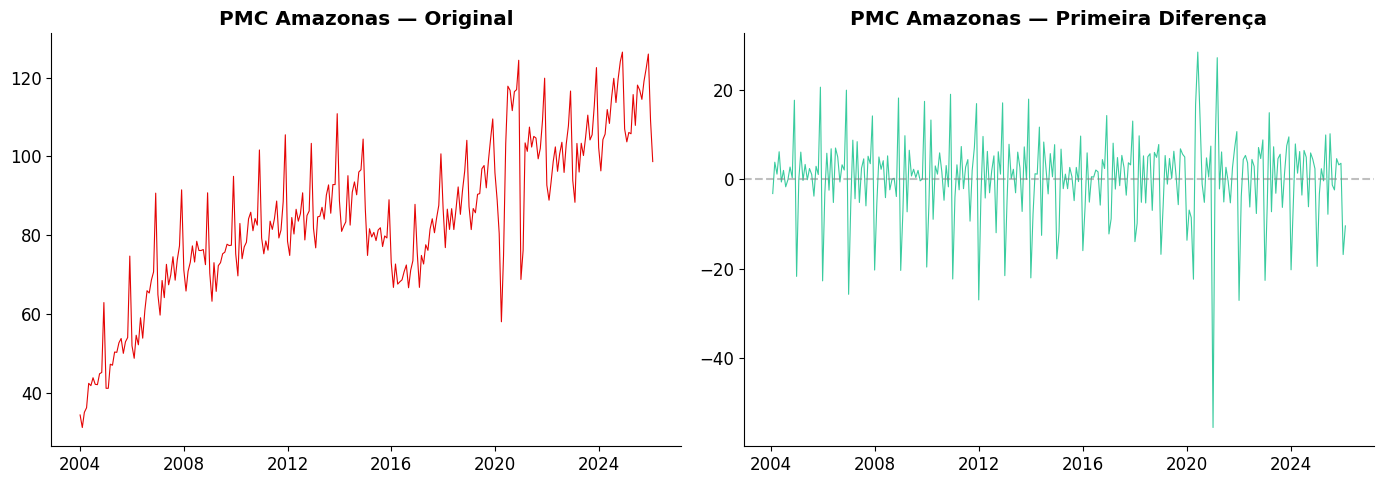

Testes de Estacionariedade — PMC Amazonas (1ª diferença)

Teste ADF (H0: raiz unitária)
  Estatística: -3.8916
  p-valor:     0.0021
  → Rejeita H0: evidência de estacionariedade

Teste KPSS (H0: estacionária)
  Estatística: 0.2467
  p-valor:     0.1000
  → Não rejeita H0: evidência de estacionariedade

CONCLUSÃO: Série provavelmente ESTACIONÁRIA


In [11]:
# Primeira diferença
y_diff = df_sf["y"].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_sf["ds"], df_sf["y"], color=INSPER_RED, linewidth=0.8)
axes[0].set_title('PMC Amazonas — Original', fontweight='bold')

axes[1].plot(df_sf["ds"][1:], y_diff, color=INSPER_TURQUESA, linewidth=0.8)
axes[1].set_title('PMC Amazonas — Primeira Diferença', fontweight='bold')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Testes na série diferenciada
testar_estacionariedade(y_diff, f'PMC {MINHA_UF} (1ª diferença)')

In [12]:
sf = StatsForecast(
    models=[AutoARIMA(season_length=12)],
    freq='MS'
)

sf.fit(df_sf)

# Ver o modelo escolhido
fitted_model = sf.fitted_[0][0].model_
print(f"Modelo escolhido: SARIMA{fitted_model['arma']}")
print(fitted_model)

Modelo escolhido: SARIMA(2, 2, 1, 1, 12, 0, 1)
{'coef': {'ar1': 1.2100986684797532, 'ar2': -0.2356565068952946, 'ma1': -0.4229046869335915, 'ma2': -0.30464580022929344, 'sar1': 0.058292366881349054, 'sma1': -0.8580605750559916, 'drift': 0.18317931954208555}, 'sigma2': 23.450035564873975, 'var_coef': array([[ 0.00337974, -0.00344086,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ],
       [-0.00344086,  0.00351353,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.00393701,  0.        ,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.00393701,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.00390984,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.00393701,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0. 

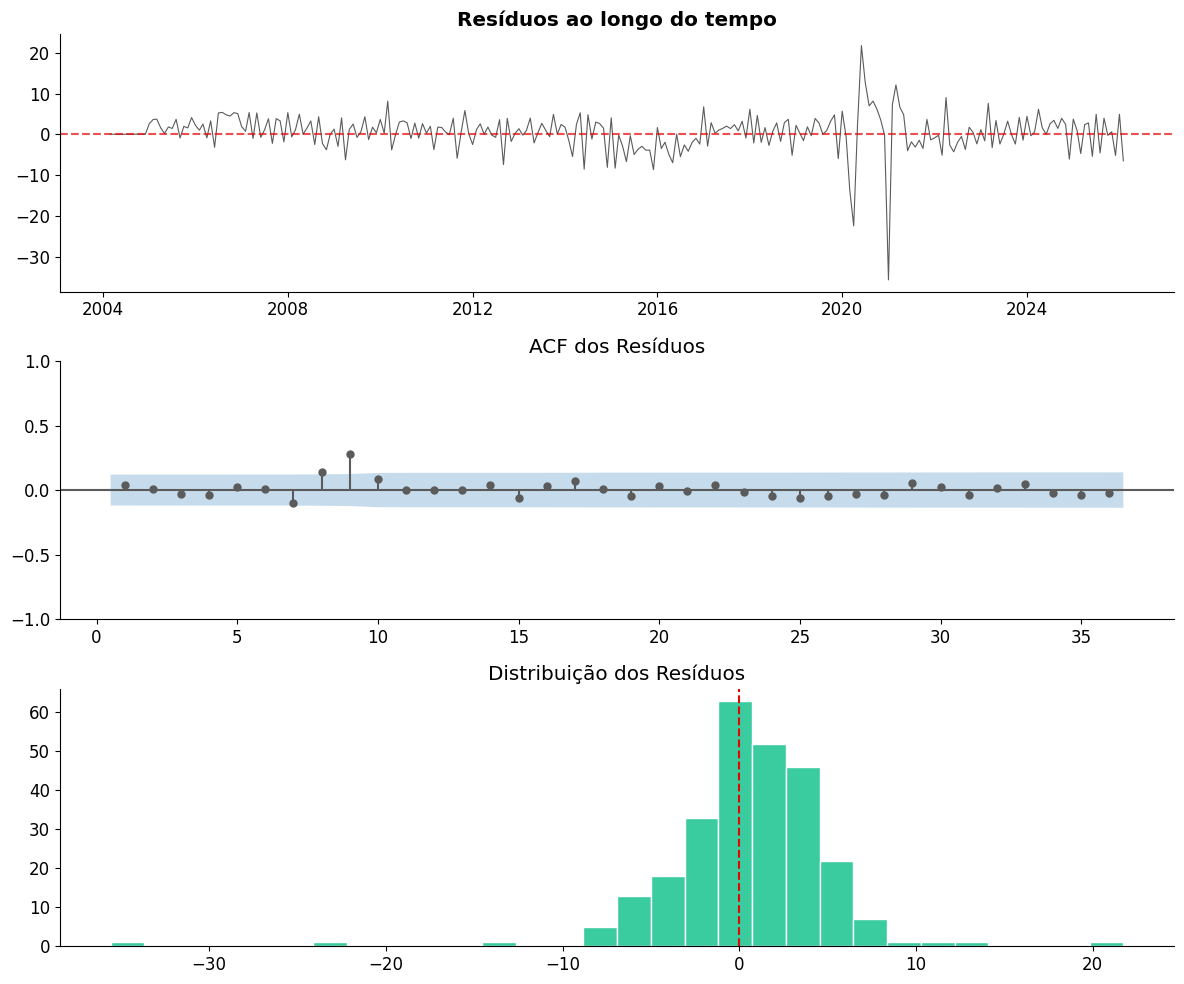

In [13]:
residuos = fitted_model['residuals']

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Resíduos ao longo do tempo
axes[0].plot(df_sf["ds"][2:], residuos[2:], color=INSPER_GRAY, linewidth=0.8)
axes[0].axhline(y=0, color=INSPER_RED, linestyle='--', alpha=0.7)
axes[0].set_title('Resíduos ao longo do tempo', fontweight='bold')

# ACF dos resíduos
plot_acf(residuos, ax=axes[1], lags=36, zero=False,
         color=INSPER_GRAY, vlines_kwargs={'colors': INSPER_GRAY})
axes[1].set_title('ACF dos Resíduos')

# Histograma dos resíduos
axes[2].hist(residuos, bins=30, color=INSPER_TURQUESA, edgecolor='white')
axes[2].set_title('Distribuição dos Resíduos')
axes[2].axvline(x=0, color=INSPER_RED, linestyle='--')

plt.tight_layout()
plt.show()

## Previsão · 24 meses à frente

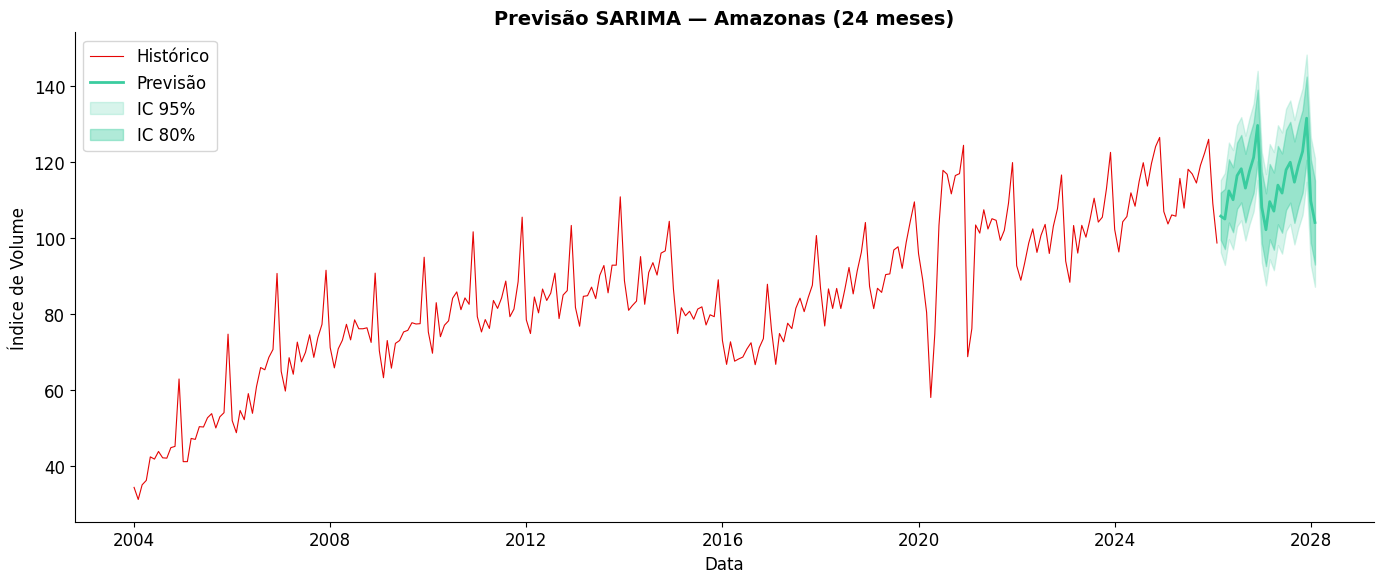

In [17]:
forecast = sf.forecast(df=df_sf, h=24, level=[80, 95])

fig, ax = plt.subplots(figsize=(14, 6))

# Histórico
ax.plot(df_sf["ds"], df_sf["y"], color=INSPER_RED, linewidth=0.8, label="Histórico")

# Previsão
ax.plot(forecast["ds"], forecast["AutoARIMA"], color=INSPER_TURQUESA, linewidth=2, label="Previsão")

# Intervalo 95%
ax.fill_between(forecast["ds"],
                forecast["AutoARIMA-lo-95"],
                forecast["AutoARIMA-hi-95"],
                alpha=0.2, color=INSPER_TURQUESA, label="IC 95%")

# Intervalo 80%
ax.fill_between(forecast["ds"],
                forecast["AutoARIMA-lo-80"],
                forecast["AutoARIMA-hi-80"],
                alpha=0.4, color=INSPER_TURQUESA, label="IC 80%")

ax.set_title(f'Previsão SARIMA — {MINHA_UF} (24 meses)', fontweight='bold', fontsize=14)
ax.set_xlabel("Data")
ax.set_ylabel("Índice de Volume")
ax.legend()

plt.tight_layout()
plt.show()

## Discussão

Escreva 4-5 linhas comentando:

1. O ACF/PACF da série original sugeriu sazonalidade? E tendência? Bate com o que você viu no gráfico de linha?

    Sim. Através do gráfico de linha já era possível perceber que as vendas no Amazonas foram crescendo bastante desde 2004, com uma queda brusca em 2020 muito provavelmente causada pela pandemia. A ACF confirmou isso com o decaimento exponencial do gráfico, o que indica que o passado influencia muito o presente (tendência forte). Também dá pra notar que os valores se repetem em ciclos de 12 meses, o que faz sentido pela esperada sazonalidade no setor de vendas graças a períodos de férias e datas comemorativas. .

2. Quantas diferenças (regular e sazonal) o AutoARIMA aplicou? E os componentes AR/MA? Conseguiu observar isso no ACF/PACF?

    O AutoARIMA escolheu o modelo SARIMA(2,2,1)(1,1,0)[12], ou seja, precisou de 2 diferenciações regulares para remover a tendência de crescimento, e mais 1 diferenciação sazonal para lidar com os ciclos de 12 meses. Isso faz sentido com o que vimos nos testes ADF e KPSS, que mostraram que a série original não era estacionária. O modelo também usou os 2 meses anteriores para ajudar na previsão (AR=2) e considerou o erro do mês passado para se corrigir (MA=1).

3. Os resíduos parecem white noise? Algum padrão remanescente sazonal?

    No geral sim. A ACF dos resíduos ficou praticamente toda dentro do intervalo de confiança, o que significa que o modelo capturou bem os padrões dos dados e o que sobrou é praticamente aleatório. O único sinal fora do normal foi o pico em 2020, que é o choque da COVID-19, o que é de se esperar por ter sido um evento fora do padrão, dificultando entrar corretamente no modelo. Fora isso, o histograma dos erros ficou centrado em zero, o que é um bom sinal.

4. A previsão pareceu razoável visualmente (captura a sazonalidade, fica bem ancorada no histórico, intervalos abrem muito com o horizonte)?

    Sim, a previsão pareceu bem razoável. Ela continua no mesmo nível do histórico recente e mantém o padrão de oscilação mensal que vemos na série original. Os intervalos de confiança abrem um pouco com o tempo, o que é esperado pois, quanto mais longe no futuro a previsão, maior a dificuldade e incerteza do que está sendo previsto. Poré, não abriram de forma exagerada, o que indica que o modelo está confiante na sua previsão.

5. Que outras UFs você imagina que dariam um SARIMA bem diferente do seu (e por quê)? Pense em estados de regiões diferentes, com perfil econômico distinto.

    Acre e Roraima provavelmente dariam modelos bem diferentes, pois são estados menores e com economia menos diversificada, o que tende a gerar séries mais irregulares e difíceis de modelar. O Rio Grande do Sul também seria interessante de comparar, pois tem uma economia forte no agronegócio, com sazonalidade ligada às safras dos alimenotos, bem diferente do Amazonas, que é muito influenciado pelo setor industrial. Essas diferenças regionais provavelmente resultariam em modelos com parâmetros e diferenciações bem distintos.